In [1]:
import torch

In [2]:
print(torch.__version__)

2.9.1+cpu


In [3]:
!nvidia-smi

Sun Nov 23 22:40:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.57                 Driver Version: 581.57         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:07:00.0  On |                  N/A |
| 31%   47C    P0             42W /  170W |    1813MiB /  12288MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Load your video and the XML bounding boxes.

In [4]:
import os
import glob
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ---- CONFIGURATION ----
ROOT_DIR = "F:/IDDPedestrian"

# Correct directories based on your structure
VIDEO_DIR = os.path.join(ROOT_DIR, "videos", "gopro", "gp_set_0001")
ANNOTATION_DIR = os.path.join(ROOT_DIR, "annotations", "gopro", "annotations", "gopro", "gp_set_0001")

print(f"Scanning for videos in: {VIDEO_DIR}")
print(f"Scanning for annotations in: {ANNOTATION_DIR}")

# Load all video files (GoPro uses MP4)
video_files = glob.glob(os.path.join(VIDEO_DIR, "*.MP4"))
print("Found videos:", len(video_files))

# Load all annotation XML files
annotation_files = glob.glob(os.path.join(ANNOTATION_DIR, "*.xml"))
print("Found annotations:", len(annotation_files))


Scanning for videos in: F:/IDDPedestrian\videos\gopro\gp_set_0001
Scanning for annotations in: F:/IDDPedestrian\annotations\gopro\annotations\gopro\gp_set_0001
Found videos: 8
Found annotations: 7


In [5]:
def get_dataset_pairs(video_root, annotation_root):
    """
    Walk through the video directory, find MP4 videos, 
    and match them with XML annotations.
    """
    dataset_pairs = []

    for root, dirs, files in os.walk(video_root):
        for file in files:

            # --- FIX 1: skip hidden MacOS files ---
            if file.startswith("._"):
                continue

            # --- FIX 2: match both .mp4 and .MP4 ---
            if file.lower().endswith(".mp4"):
                video_path = os.path.join(root, file)

                # Relative folder inside video root
                relative_path = os.path.relpath(root, video_root)

                # --- FIX 3: force XML extension in lowercase ---
                base_name = os.path.splitext(file)[0]   # removes .mp4 or .MP4
                xml_filename = base_name + ".xml"

                expected_xml_path = os.path.join(annotation_root, relative_path, xml_filename)

                if os.path.exists(expected_xml_path):
                    dataset_pairs.append((video_path, expected_xml_path))
                else:
                    print(f"Warning: XML not found for: {video_path}")
                    print(f"Expected at: {expected_xml_path}")

    return dataset_pairs


# Run again
pairs = get_dataset_pairs(VIDEO_DIR, ANNOTATION_DIR)
print(f"Found {len(pairs)} valid video-annotation pairs.")

if len(pairs) > 0:
    print("Sample pair:")
    print("Video:", pairs[0][0])
    print("XML:  ", pairs[0][1])


Expected at: F:/IDDPedestrian\annotations\gopro\annotations\gopro\gp_set_0001\.\gp_set_0001_vid_0004.xml
Found 7 valid video-annotation pairs.
Sample pair:
Video: F:/IDDPedestrian\videos\gopro\gp_set_0001\gp_set_0001_vid_0001.MP4
XML:   F:/IDDPedestrian\annotations\gopro\annotations\gopro\gp_set_0001\.\gp_set_0001_vid_0001.xml


In [6]:
def parse_cvat_xml(xml_file):
    """
    Parses CVAT XML to extract bounding boxes per frame.
    Returns a dictionary: { frame_number: [ {'label': str, 'bbox': [x1, y1, x2, y2]} ] }
    """
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    frames_data = {}
    
    for track in root.findall('track'):
        label = track.get('label')

        for box in track.findall('box'):
            frame_num = int(box.get('frame'))

            xtl = float(box.get('xtl'))
            ytl = float(box.get('ytl'))
            xbr = float(box.get('xbr'))
            ybr = float(box.get('ybr'))

            occluded = int(box.get('occluded', 0))

            box_info = {
                'label': label,
                'bbox': [xtl, ytl, xbr, ybr],
                'occluded': occluded
            }

            if frame_num not in frames_data:
                frames_data[frame_num] = []
            frames_data[frame_num].append(box_info)
    
    return frames_data


In [7]:
def visualize_frame(video_path, xml_data, frame_to_show=0):
    """
    Loads a specific frame from video and overlays parsed CVAT XML bounding boxes.
    xml_data must be the output of parse_cvat_xml(), i.e.:
        { frame_number: [ {'label': str, 'bbox': [x1,y1,x2,y2], 'occluded': int} ] }
    """

    cap = cv2.VideoCapture(video_path)

    # Go to the requested frame index
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_to_show)
    ret, frame = cap.read()

    if not ret:
        print(f"Error: Could not read frame {frame_to_show} from {video_path}")
        cap.release()
        return

    # Convert BGR → RGB for Matplotlib
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Get annotation list for this frame
    boxes = xml_data.get(frame_to_show, [])

    # Draw boxes
    for item in boxes:
        x1, y1, x2, y2 = map(int, item['bbox'])
        label = item['label']
        occluded = item.get('occluded', 0)

        # Color: pedestrian = green, others = red
        color = (0, 255, 0) if label.lower() == "pedestrian" else (255, 0, 0)

        # If occluded, use dashed or different color (optional improvement)
        if occluded:
            color = (0, 200, 255)   # orange-blue mix for occlusion

        # Draw rectangle
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # Draw label background
        label_bg_end = x1 + max(80, len(label) * 10)
        cv2.rectangle(frame, (x1, y1 - 20), (label_bg_end, y1), color, -1)

        # Put label text
        cv2.putText(frame, label, (x1 + 5, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (255, 255, 255), 1)

    cap.release()

    # Display result
    plt.figure(figsize=(12, 8))
    plt.imshow(frame)
    plt.title(f"Frame {frame_to_show} | Annotations: {len(boxes)}")
    plt.axis("off")
    plt.show()


Processing video: gp_set_0001_vid_0001.MP4
Using annotation: gp_set_0001_vid_0001.xml
Parsing XML...
Visualizing annotated frame: 7044


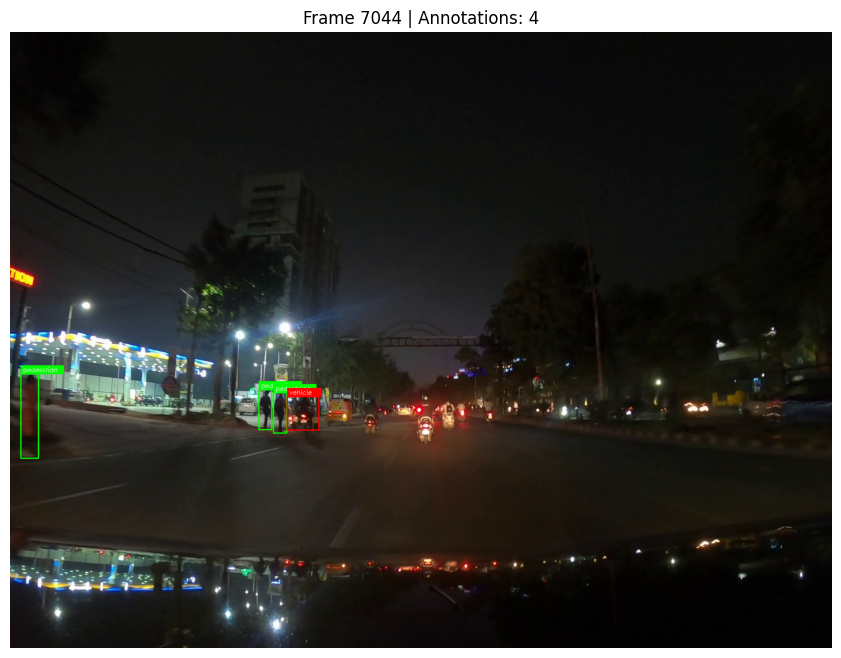

In [8]:
# 1. Select the first available video–XML pair
if len(pairs) > 0:
    target_video, target_xml = pairs[0]

    print(f"Processing video: {os.path.basename(target_video)}")
    print(f"Using annotation: {os.path.basename(target_xml)}")

    # 2. Parse XML annotations
    print("Parsing XML...")
    annotations = parse_cvat_xml(target_xml)

    # 3. Identify frames with annotations
    annotated_frames = sorted(annotations.keys())

    if annotated_frames:
        # Choose a frame roughly in the middle of annotated frames
        demo_frame = annotated_frames[len(annotated_frames) // 2]

        print(f"Visualizing annotated frame: {demo_frame}")

        # 4. Visualize the selected frame
        visualize_frame(
            video_path=target_video,
            xml_data=annotations,
            frame_to_show=demo_frame
        )
    else:
        print("Warning: This XML file contains no frame annotations.")

else:
    print("No video/XML pairs found. Verify the directory paths in Cell 1.")


In [9]:
# --- PREVIEW MULTIPLE ANNOTATED FRAMES ---
def preview_annotated_frames(video_path, xml_data, num_frames=5):
    """
    Displays multiple annotated frames evenly spaced across all annotated frames.
    """
    annotated_frames = sorted(xml_data.keys())

    if not annotated_frames:
        print("No annotated frames available.")
        return

    # If fewer annotations exist than requested, just show all
    num_frames = min(num_frames, len(annotated_frames))

    # Evenly choose frames across the annotation timeline
    step = len(annotated_frames) // num_frames
    selected_frames = [annotated_frames[i * step] for i in range(num_frames)]

    print(f"Previewing {len(selected_frames)} annotated frames:")
    print(selected_frames)

    for frame_idx in selected_frames:
        print(f"\nShowing frame {frame_idx}")
        visualize_frame(video_path, xml_data, frame_to_show=frame_idx)


Previewing 6 annotated frames:
[38, 2303, 5350, 7043, 8439, 12849]

Showing frame 38


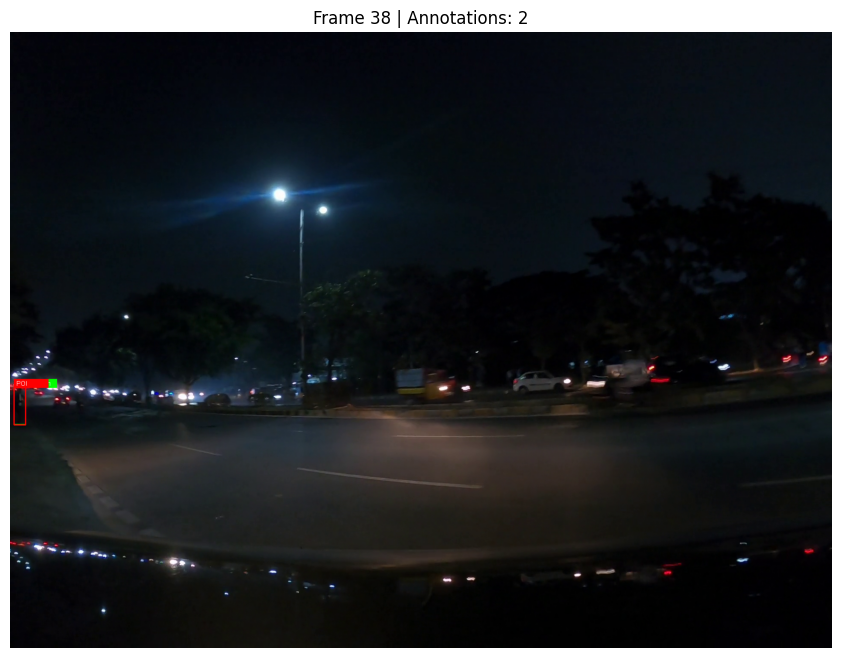


Showing frame 2303


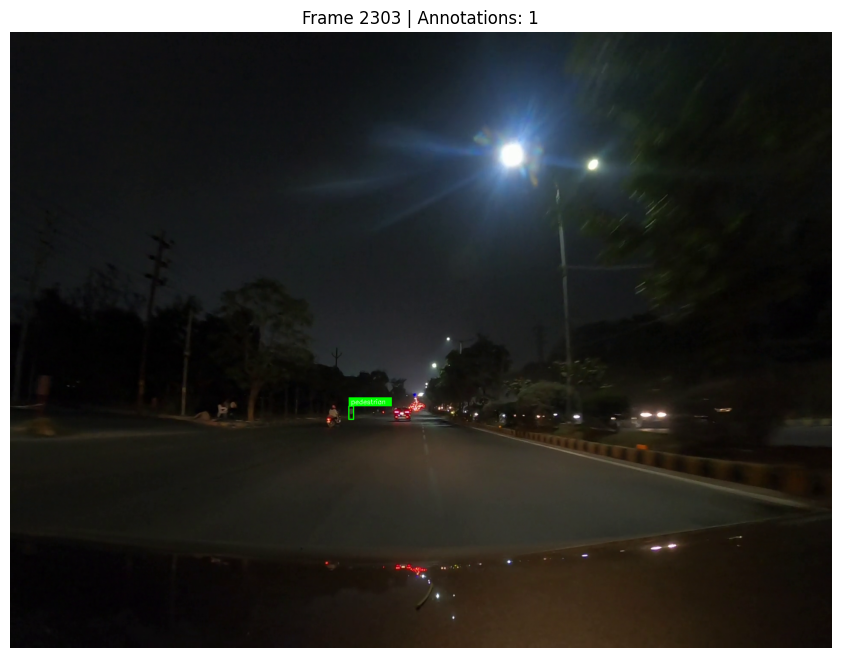


Showing frame 5350


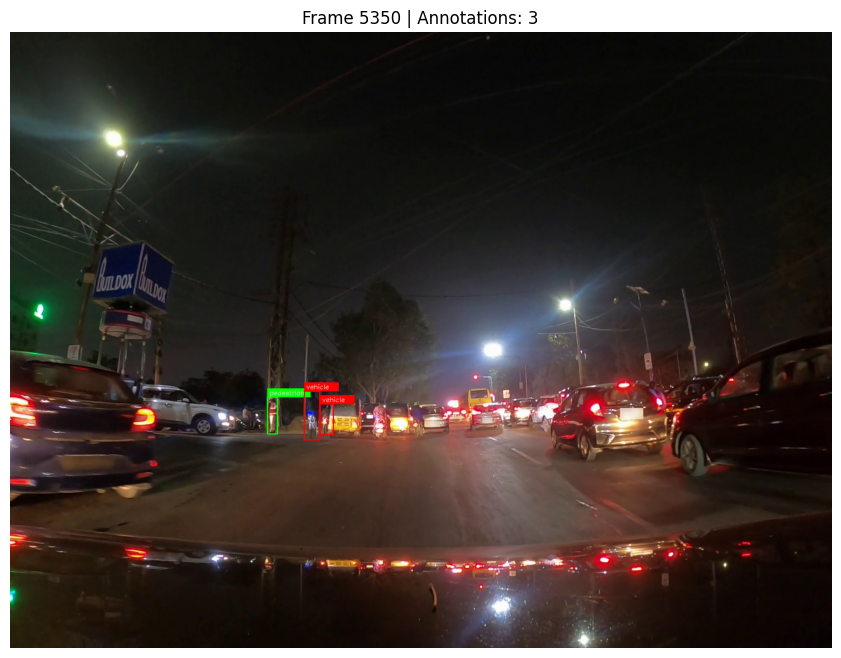


Showing frame 7043


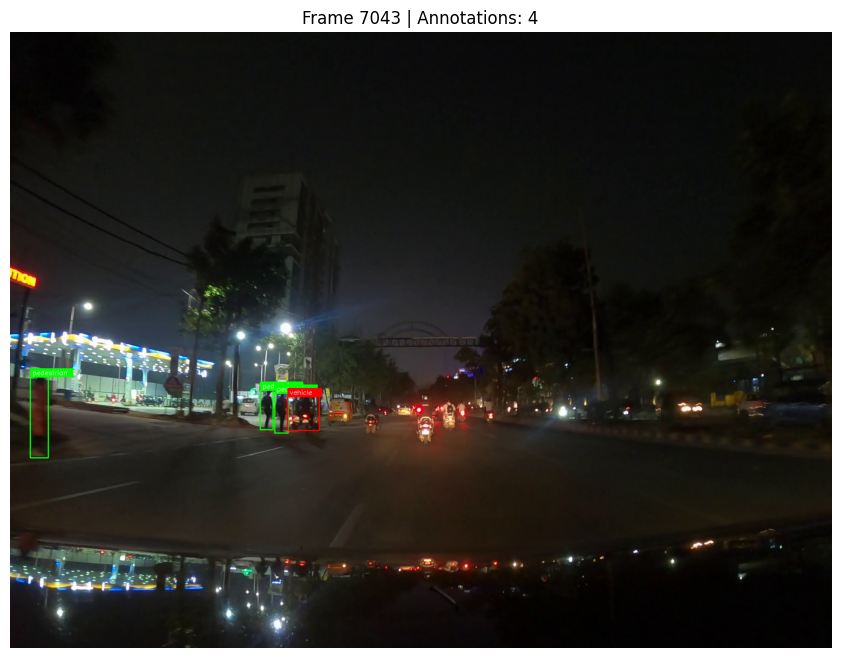


Showing frame 8439


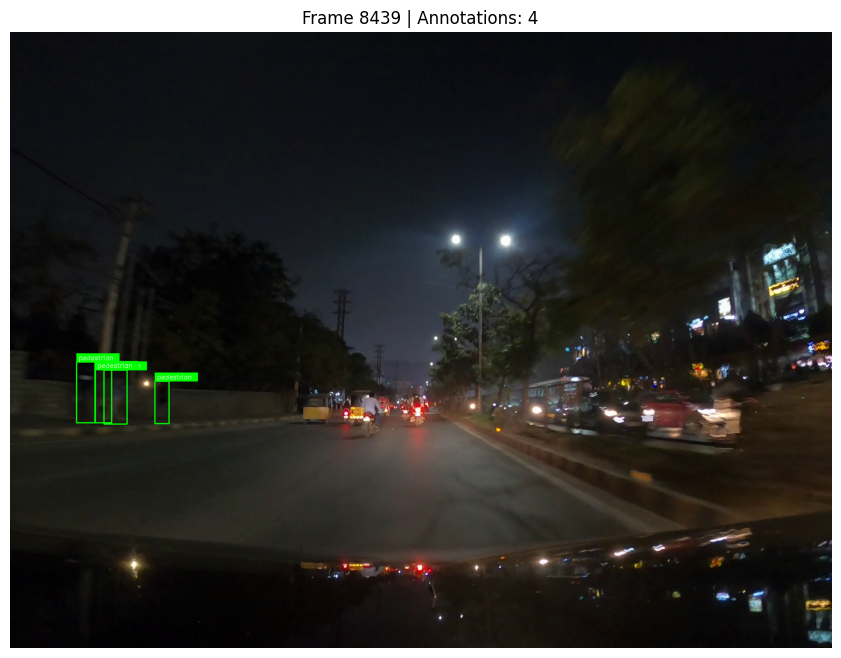


Showing frame 12849


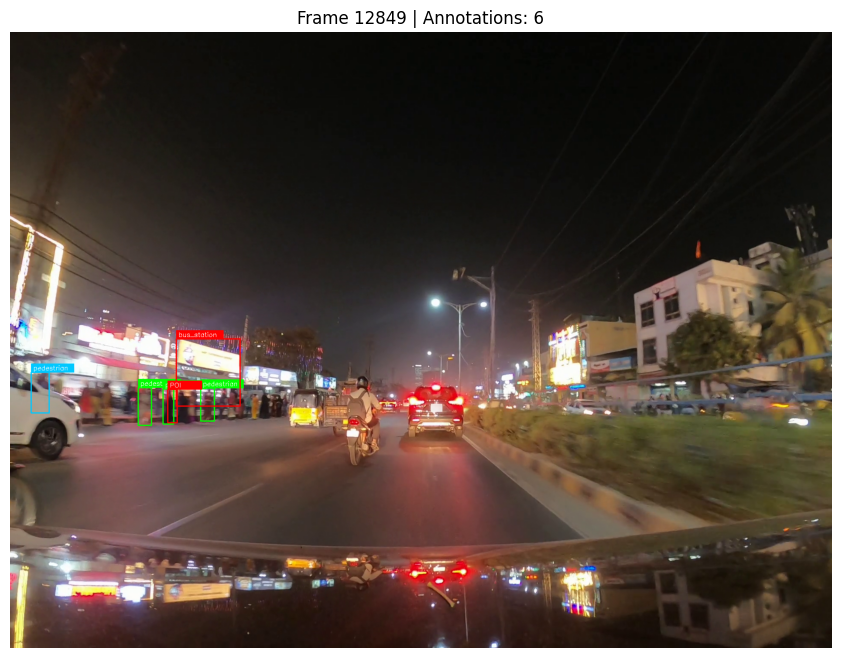

In [10]:
preview_annotated_frames(target_video, annotations, num_frames=6)


In [11]:
import cv2
import os

def export_annotated_video(video_path, xml_data, output_path="annotated_output.mp4"):
    """
    Exports a new video file with bounding boxes drawn on each frame.
    
    Parameters:
        video_path  : path to the original video
        xml_data    : parsed XML annotation dictionary from parse_cvat_xml()
        output_path : filename for the exported annotated video
    """

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Unable to open video: {video_path}")
        return

    # --- Video properties ---
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Video FPS: {fps}, Resolution: {width}x{height}, Total frames: {total_frames}")

    # --- Video Writer ---
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")  # MP4 codec
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break  # end of video

        # Get boxes for this frame (if any)
        boxes = xml_data.get(frame_idx, [])

        # Draw annotations
        for item in boxes:
            x1, y1, x2, y2 = map(int, item["bbox"])
            label = item["label"]
            occluded = item.get("occluded", 0)

            # Color: green = pedestrian, red = others
            color = (0, 255, 0) if label.lower() == "pedestrian" else (0, 0, 255)
            if occluded:
                color = (0, 200, 255)  # different color for occlusion

            # Draw bounding box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # Label background
            label_width = max(80, len(label) * 10)
            cv2.rectangle(frame, (x1, y1 - 20), (x1 + label_width, y1), color, -1)

            # Text
            cv2.putText(frame, label, (x1 + 5, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (255, 255, 255), 1)

        # Write updated frame to output
        out.write(frame)

        frame_idx += 1

    cap.release()
    out.release()

    print(f"Annotated video saved to: {output_path}")


In [12]:
export_annotated_video(target_video, annotations,
                       output_path="annotated_" + os.path.basename(target_video))


Video FPS: 30.0, Resolution: 1920x1440, Total frames: 15930
Annotated video saved to: annotated_gp_set_0001_vid_0001.MP4


In [13]:
from ipywidgets import interact, IntSlider
import ipywidgets as widgets
import cv2

def interactive_frame_viewer(video_path, xml_data):
    """
    Creates a GUI slider to scroll through all frames of a video
    with XML annotations overlaid.
    """

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Could not open video.")
        return
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    print(f"Loaded video: {os.path.basename(video_path)}")
    print(f"Total frames: {total_frames}")

    slider = IntSlider(
        value=0,
        min=0,
        max=total_frames - 1,
        step=1,
        description='Frame:',
        continuous_update=False
    )

    @interact(frame_index=slider)
    def show_frame(frame_index):
        visualize_frame(video_path, xml_data, frame_to_show=frame_index)


In [14]:
interactive_frame_viewer(target_video, annotations)


Loaded video: gp_set_0001_vid_0001.MP4
Total frames: 15930


interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame:', max=15929), Output()),…

# Vehicle annotations added

In [15]:
import os
import glob
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ---- CONFIGURATION ----
ROOT_DIR = "F:/IDDPedestrian"

# 1. Video Directory (Keep existing)
VIDEO_DIR = os.path.join(ROOT_DIR, "videos", "gopro", "gp_set_0001")

# 2. Pedestrian Annotation Directory (Keep existing as you confirmed it works)
PED_ANNOTATION_DIR = os.path.join(ROOT_DIR, "annotations", "gopro", "annotations", "gopro", "gp_set_0001")

# 3. Vehicle Annotation Directory (Updated based on screenshot breadcrumb)
# Path: IDDPedestrian -> vehicle_annotations -> annotations_vehicle -> gopro -> gp_set_0001
VEH_ANNOTATION_DIR = os.path.join(ROOT_DIR, "vehicle_annotations", "annotations_vehicle", "gopro", "gp_set_0001")

print(f"1. Videos:      {VIDEO_DIR}")
print(f"2. Pedestrian:  {PED_ANNOTATION_DIR}")
print(f"3. Vehicle:     {VEH_ANNOTATION_DIR}")

# ---- VERIFICATION ----
video_files = glob.glob(os.path.join(VIDEO_DIR, "*.MP4"))
ped_files = glob.glob(os.path.join(PED_ANNOTATION_DIR, "*.xml"))
veh_files = glob.glob(os.path.join(VEH_ANNOTATION_DIR, "*.xml"))

print("\n--- File Counts ---")
print(f"Videos Found:     {len(video_files)}")
print(f"Pedestrian XMLs:  {len(ped_files)}")
print(f"Vehicle XMLs:     {len(veh_files)}")

if len(veh_files) == 0:
    print("\nWARNING: No Vehicle XMLs found! Check if the folder contains .xml files.")
    # Debug: List first 5 files in that directory to see what's there
    try:
        all_files = os.listdir(VEH_ANNOTATION_DIR)
        print(f"Files actually in vehicle dir: {all_files[:5]}")
    except FileNotFoundError:
        print("ERROR: The vehicle directory path does not exist.")

1. Videos:      F:/IDDPedestrian\videos\gopro\gp_set_0001
2. Pedestrian:  F:/IDDPedestrian\annotations\gopro\annotations\gopro\gp_set_0001
3. Vehicle:     F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0001

--- File Counts ---
Videos Found:     8
Pedestrian XMLs:  7
Vehicle XMLs:     7


In [16]:
import os
import glob
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ---- CONFIGURATION ----
# Based on your "This PC > New Volume (F:) > IDDPedestrian"
ROOT_DIR = "F:/IDDPedestrian"

# 1. Video Directory
VIDEO_DIR = os.path.join(ROOT_DIR, "videos", "gopro", "gp_set_0001")

# 2. Pedestrian Annotation Directory 
# (Based on your text output: annotations/gopro/annotations/gopro/gp_set_0001)
PED_ANNOTATION_DIR = os.path.join(ROOT_DIR, "annotations", "gopro", "annotations", "gopro", "gp_set_0001")

# 3. Vehicle Annotation Directory 
# (Based on screenshot: vehicle_annotations/annotations_vehicle/gopro/gp_set_0001)
VEH_ANNOTATION_DIR = os.path.join(ROOT_DIR, "vehicle_annotations", "annotations_vehicle", "gopro", "gp_set_0001")

print(f"1. Videos Path:     {VIDEO_DIR}")
print(f"2. Pedestrian Path: {PED_ANNOTATION_DIR}")
print(f"3. Vehicle Path:    {VEH_ANNOTATION_DIR}")

# ---- VERIFICATION ----
video_files = glob.glob(os.path.join(VIDEO_DIR, "*.MP4"))
ped_files = glob.glob(os.path.join(PED_ANNOTATION_DIR, "*.xml"))
veh_files = glob.glob(os.path.join(VEH_ANNOTATION_DIR, "*.xml"))

print("\n--- File Counts ---")
print(f"Videos Found:     {len(video_files)}")
print(f"Pedestrian XMLs:  {len(ped_files)}")
print(f"Vehicle XMLs:     {len(veh_files)}")

1. Videos Path:     F:/IDDPedestrian\videos\gopro\gp_set_0001
2. Pedestrian Path: F:/IDDPedestrian\annotations\gopro\annotations\gopro\gp_set_0001
3. Vehicle Path:    F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0001

--- File Counts ---
Videos Found:     8
Pedestrian XMLs:  7
Vehicle XMLs:     7


In [17]:
def get_dataset_triplets_smart(video_dir, ped_dir, veh_dir):
    """
    Indexes files and performs smart matching. 
    If exact match fails, it tries to match based on substrings.
    """
    triplets = []

    def get_file_map(directory):
        file_map = {}
        if os.path.exists(directory):
            for f in os.listdir(directory):
                if f.lower().endswith('.xml'):
                    # Store: { 'clean_name': full_path }
                    key = os.path.splitext(f)[0].lower()
                    file_map[key] = os.path.join(directory, f)
        return file_map

    # 1. Index XMLs
    ped_map = get_file_map(ped_dir)
    veh_map = get_file_map(veh_dir)

    # DEBUG: Print what we actually found in the vehicle folder
    print(f"--- DEBUG: Found {len(veh_map)} Vehicle XML keys ---")
    if len(veh_map) > 0:
        print(f"Sample Vehicle XML keys: {list(veh_map.keys())[:3]}")
    else:
        print("ERROR: No Vehicle XMLs found in the directory provided!")

    # 2. Match Videos
    if os.path.exists(video_dir):
        for f in os.listdir(video_dir):
            if f.startswith("._"): continue 
            
            if f.lower().endswith(".mp4"):
                video_path = os.path.join(video_dir, f)
                video_base = os.path.splitext(f)[0].lower()
                
                # -- PEDESTRIAN MATCHING --
                ped_xml = ped_map.get(video_base)
                
                # -- VEHICLE MATCHING (Smart Logic) --
                veh_xml = veh_map.get(video_base)
                
                # If exact match failed, try fuzzy search in veh_map
                if not veh_xml:
                    for v_key, v_path in veh_map.items():
                        # Check if one is a substring of the other (e.g. 'vid_0001' inside 'gp_set_0001_vid_0001')
                        if (v_key in video_base) or (video_base in v_key):
                            veh_xml = v_path
                            break

                # Only add if at least one annotation exists
                if ped_xml or veh_xml:
                    triplets.append((video_path, ped_xml, veh_xml))

    return triplets

# Run the smart matching
pairs = get_dataset_triplets_smart(VIDEO_DIR, PED_ANNOTATION_DIR, VEH_ANNOTATION_DIR)

print(f"\nMatched {len(pairs)} videos with annotation files.")

if len(pairs) > 0:
    v, p, x = pairs[0]
    print("\nSample Match:")
    print(f"Video:   {os.path.basename(v)}")
    print(f"Ped XML: {os.path.basename(p) if p else 'None'}")
    print(f"Veh XML: {os.path.basename(x) if x else 'None'}")
else:
    print("No matches found.")

--- DEBUG: Found 14 Vehicle XML keys ---
Sample Vehicle XML keys: ['._gp_set_0001_vid_0001_obd', '._gp_set_0001_vid_0002_obd', '._gp_set_0001_vid_0003_obd']

Matched 7 videos with annotation files.

Sample Match:
Video:   gp_set_0001_vid_0001.MP4
Ped XML: gp_set_0001_vid_0001.xml
Veh XML: ._gp_set_0001_vid_0001_obd.xml


In [18]:
def parse_cvat_xml(xml_file):
    """
    Parses CVAT XML to extract bounding boxes per frame.
    """
    if xml_file is None:
        return {}

    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        frames_data = {}
        
        for track in root.findall('track'):
            label = track.get('label')

            for box in track.findall('box'):
                frame_num = int(box.get('frame'))
                xtl = float(box.get('xtl'))
                ytl = float(box.get('ytl'))
                xbr = float(box.get('xbr'))
                ybr = float(box.get('ybr'))
                occluded = int(box.get('occluded', 0))

                box_info = {
                    'label': label,
                    'bbox': [xtl, ytl, xbr, ybr],
                    'occluded': occluded
                }

                if frame_num not in frames_data:
                    frames_data[frame_num] = []
                frames_data[frame_num].append(box_info)
        
        return frames_data
    except Exception as e:
        print(f"Error parsing {xml_file}: {e}")
        return {}

In [19]:
def visualize_frame(video_path, xml_data, frame_to_show=0):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_to_show)
    ret, frame = cap.read()

    if not ret:
        print(f"Error: Could not read frame {frame_to_show}")
        cap.release()
        return

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    boxes = xml_data.get(frame_to_show, [])

    for item in boxes:
        x1, y1, x2, y2 = map(int, item['bbox'])
        label = item['label']
        occluded = item.get('occluded', 0)

        # Color Logic
        label_lower = label.lower()
        if 'pedestrian' in label_lower or 'rider' in label_lower:
            color = (0, 255, 0) # Green
        elif 'vehicle' in label_lower or 'car' in label_lower or 'bus' in label_lower or 'truck' in label_lower:
            color = (255, 0, 0) # Red
        else:
            color = (255, 255, 0) # Yellow/Cyan

        if occluded:
            color = (255, 165, 0) 

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
        text = f"{label}"
        cv2.putText(frame, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    cap.release()

    plt.figure(figsize=(14, 10))
    plt.imshow(frame)
    plt.title(f"Frame {frame_to_show} | Objects: {len(boxes)}")
    plt.axis("off")
    plt.show()

Processing Video: gp_set_0001_vid_0001.MP4
Parsing Pedestrian XML: gp_set_0001_vid_0001.xml
Parsing Vehicle XML:    ._gp_set_0001_vid_0001_obd.xml
Error parsing F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0001\._gp_set_0001_vid_0001_obd.xml: not well-formed (invalid token): line 1, column 0
Total objects loaded: 10479

Visualizing Frame: 7044


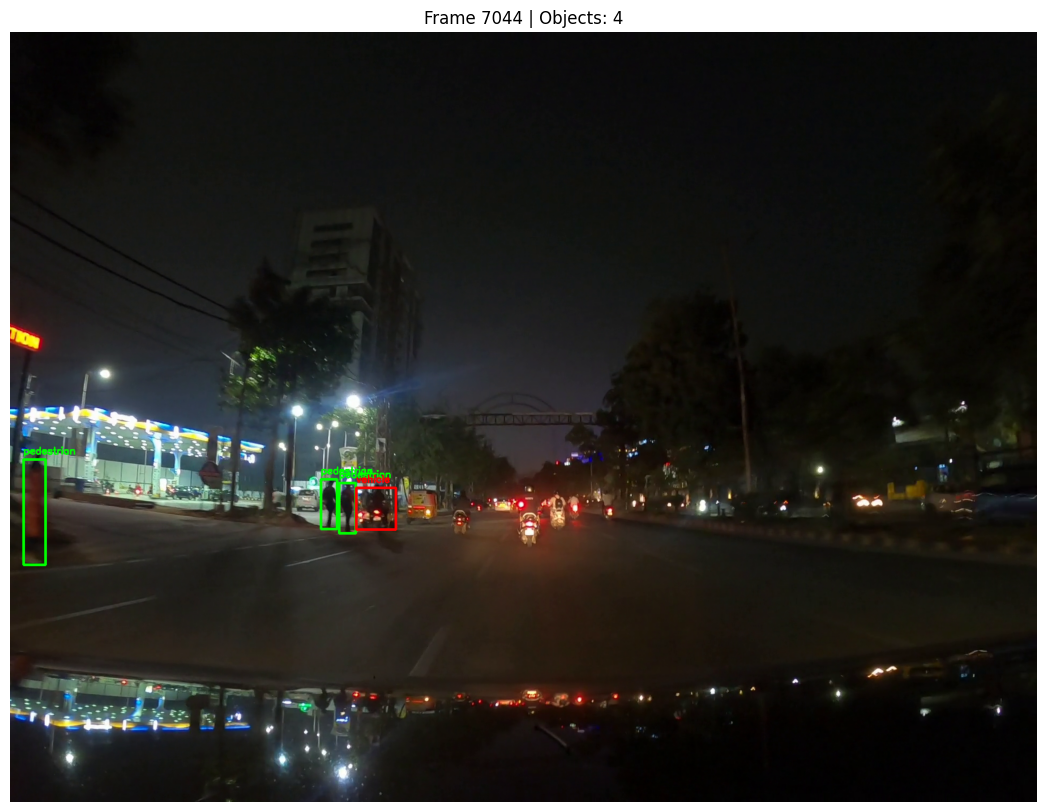

In [20]:
if len(pairs) > 0:
    # 1. Select the first matching pair
    video_path, ped_xml, veh_xml = pairs[0]
    print(f"Processing Video: {os.path.basename(video_path)}")

    combined_annotations = {}

    def merge_data(target_dict, source_dict):
        for fr, objs in source_dict.items():
            if fr not in target_dict:
                target_dict[fr] = []
            target_dict[fr].extend(objs)

    # 2. Parse Pedestrian Data
    if ped_xml:
        print(f"Parsing Pedestrian XML: {os.path.basename(ped_xml)}")
        ped_data = parse_cvat_xml(ped_xml)
        merge_data(combined_annotations, ped_data)
    else:
        print("No Pedestrian XML found for this video.")
        
    # 3. Parse Vehicle Data
    if veh_xml:
        print(f"Parsing Vehicle XML:    {os.path.basename(veh_xml)}")
        veh_data = parse_cvat_xml(veh_xml)
        merge_data(combined_annotations, veh_data)
    else:
        print("No Vehicle XML found for this video.")

    total_objects = sum(len(v) for v in combined_annotations.values())
    print(f"Total objects loaded: {total_objects}")

    # 4. Find a frame to visualize
    available_frames = sorted(combined_annotations.keys())
    
    if available_frames:
        demo_frame = available_frames[len(available_frames) // 2]
        print(f"\nVisualizing Frame: {demo_frame}")
        visualize_frame(video_path, combined_annotations, frame_to_show=demo_frame)
    else:
        print("Warning: XML files were found, but they contain no annotations.")

else:
    print("No video pairs found.")

In [21]:
from tqdm import tqdm  # Library for progress bar

def generate_annotated_video(input_video_path, xml_data, output_video_path):
    """
    Reads input video, draws bounding boxes for every frame, and saves to output_video_path.
    """
    # 1. Open Input Video
    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {input_video_path}")
        return

    # 2. Get Video Properties
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Input: {input_video_path}")
    print(f"Resolution: {width}x{height} | FPS: {fps} | Frames: {total_frames}")
    print(f"Saving to: {output_video_path}")

    # 3. Initialize Video Writer
    # 'mp4v' is a widely supported codec for .mp4
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    # 4. Process Frame by Frame
    frame_idx = 0
    
    # Use tqdm for a progress bar
    pbar = tqdm(total=total_frames, desc="Processing Video")

    while True:
        ret, frame = cap.read()
        if not ret:
            break # End of video

        # Get annotations for current frame index
        boxes = xml_data.get(frame_idx, [])

        # Draw boxes on the frame
        for item in boxes:
            x1, y1, x2, y2 = map(int, item['bbox'])
            label = item['label']
            occluded = item.get('occluded', 0)

            # ---- Color Logic (Same as Cell 5) ----
            label_lower = label.lower()
            if 'pedestrian' in label_lower or 'rider' in label_lower:
                color = (0, 255, 0) # Green
            elif 'vehicle' in label_lower or 'car' in label_lower or 'bus' in label_lower or 'truck' in label_lower:
                color = (255, 0, 0) # Red (BGR format)
            else:
                color = (0, 255, 255) # Yellow

            # Occlusion check
            if occluded:
                color = (0, 165, 255) # Orange (BGR: Blue=0, Green=165, Red=255)

            # Draw Rectangle
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # Draw Label Background
            label_text = f"{label}"
            (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(frame, (x1, y1 - 20), (x1 + text_w + 10, y1), color, -1)
            
            # Draw Text (White)
            cv2.putText(frame, label_text, (x1 + 5, y1 - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        # Write the processed frame to output file
        out.write(frame)
        
        frame_idx += 1
        pbar.update(1)

    # 5. Release Resources
    cap.release()
    out.release()
    pbar.close()
    print("\nVideo processing complete.")

In [22]:
# Check if we have pairs found from previous cells
if 'pairs' in globals() and len(pairs) > 0 and 'combined_annotations' in globals():
    
    # 1. Setup Input and Output paths
    input_video = pairs[0][0] # The video path from Cell 3/6
    
    # Create an output filename (e.g., original_name_annotated.mp4)
    base_name = os.path.splitext(os.path.basename(input_video))[0]
    output_filename = f"{base_name}_annotated.mp4"
    
    # Save it in the root directory or a specific folder
    output_path = os.path.join(ROOT_DIR, output_filename)

    # 2. Run the generator
    generate_annotated_video(
        input_video_path=input_video,
        xml_data=combined_annotations, # Using the merged data from Cell 6
        output_video_path=output_path
    )

    print(f"File saved successfully at: {output_path}")

else:
    print("Error: No video/annotation pairs found or 'combined_annotations' is missing.")
    print("Please ensure you have run Cells 1 through 6 successfully first.")

Input: F:/IDDPedestrian\videos\gopro\gp_set_0001\gp_set_0001_vid_0001.MP4
Resolution: 1920x1440 | FPS: 30.0 | Frames: 15930
Saving to: F:/IDDPedestrian\gp_set_0001_vid_0001_annotated.mp4


Processing Video: 100%|██████████████████████████| 15930/15930 [09:04<00:00, 29.28it/s]


Video processing complete.
File saved successfully at: F:/IDDPedestrian\gp_set_0001_vid_0001_annotated.mp4


# For all 9 sets

In [23]:
import os
import glob
import xml.etree.ElementTree as ET
import cv2
import numpy as np
from tqdm import tqdm

# ---- CONFIGURATION ----
ROOT_DIR = "F:/IDDPedestrian"

# Define the sets we want to process
DATA_SETS = [f"gp_set_{str(i).zfill(4)}" for i in range(1, 10)] 
# This generates: ['gp_set_0001', 'gp_set_0002', ..., 'gp_set_0009']

# Define where to save the results
OUTPUT_ROOT = os.path.join(ROOT_DIR, "annotated_results")
if not os.path.exists(OUTPUT_ROOT):
    os.makedirs(OUTPUT_ROOT)

print(f"Root Directory: {ROOT_DIR}")
print(f"Output Directory: {OUTPUT_ROOT}")
print(f"Sets to process: {DATA_SETS}")

Root Directory: F:/IDDPedestrian
Output Directory: F:/IDDPedestrian\annotated_results
Sets to process: ['gp_set_0001', 'gp_set_0002', 'gp_set_0003', 'gp_set_0004', 'gp_set_0005', 'gp_set_0006', 'gp_set_0007', 'gp_set_0008', 'gp_set_0009']


In [24]:
def parse_cvat_xml(xml_file):
    """
    Parses CVAT XML to extract bounding boxes per frame.
    Returns: { frame_number: [ {'label': str, 'bbox': [x1, y1, x2, y2], 'occluded': int} ] }
    """
    if xml_file is None:
        return {}

    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        frames_data = {}
        
        for track in root.findall('track'):
            label = track.get('label')
            for box in track.findall('box'):
                frame_num = int(box.get('frame'))
                xtl = float(box.get('xtl'))
                ytl = float(box.get('ytl'))
                xbr = float(box.get('xbr'))
                ybr = float(box.get('ybr'))
                occluded = int(box.get('occluded', 0))

                box_info = {
                    'label': label,
                    'bbox': [xtl, ytl, xbr, ybr],
                    'occluded': occluded
                }

                if frame_num not in frames_data:
                    frames_data[frame_num] = []
                frames_data[frame_num].append(box_info)
        return frames_data
    except Exception as e:
        print(f"Error parsing {xml_file}: {e}")
        return {}

def merge_data(target_dict, source_dict):
    """Merges source_dict annotations into target_dict."""
    for fr, objs in source_dict.items():
        if fr not in target_dict:
            target_dict[fr] = []
        target_dict[fr].extend(objs)

In [25]:
def get_dataset_triplets_smart(video_dir, ped_dir, veh_dir):
    """
    Indexes files and matches Video <-> Pedestrian XML <-> Vehicle XML
    """
    triplets = []

    def get_file_map(directory):
        file_map = {}
        if os.path.exists(directory):
            for f in os.listdir(directory):
                if f.lower().endswith('.xml'):
                    key = os.path.splitext(f)[0].lower()
                    file_map[key] = os.path.join(directory, f)
        return file_map

    ped_map = get_file_map(ped_dir)
    veh_map = get_file_map(veh_dir)

    if os.path.exists(video_dir):
        for f in os.listdir(video_dir):
            if f.startswith("._"): continue 
            if f.lower().endswith(".mp4"):
                video_path = os.path.join(video_dir, f)
                video_base = os.path.splitext(f)[0].lower()
                
                # Pedestrian match
                ped_xml = ped_map.get(video_base)
                
                # Vehicle match (Smart logic for substring matching)
                veh_xml = veh_map.get(video_base)
                if not veh_xml:
                    for v_key, v_path in veh_map.items():
                        if (v_key in video_base) or (video_base in v_key):
                            veh_xml = v_path
                            break

                # Only add if at least one annotation exists
                if ped_xml or veh_xml:
                    triplets.append((video_path, ped_xml, veh_xml))

    return triplets

In [26]:
def generate_annotated_video(input_video_path, xml_data, output_video_path):
    """
    Reads input video, draws boxes, saves to output.
    """
    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        print(f"Error: Could not open {input_video_path}")
        return

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Use mp4v codec
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    pbar = tqdm(total=total_frames, desc="  Rendering", leave=False)
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret: break

        boxes = xml_data.get(frame_idx, [])

        for item in boxes:
            x1, y1, x2, y2 = map(int, item['bbox'])
            label = item['label']
            occluded = item.get('occluded', 0)

            # Color Logic
            label_lower = label.lower()
            if 'pedestrian' in label_lower or 'rider' in label_lower:
                color = (0, 255, 0) # Green
            elif 'vehicle' in label_lower or 'car' in label_lower or 'bus' in label_lower or 'truck' in label_lower:
                color = (0, 0, 255) # Red (OpenCV is BGR)
            else:
                color = (0, 255, 255) # Yellow

            if occluded:
                color = (0, 165, 255) # Orange

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            
            # Label
            label_text = label
            (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(frame, (x1, y1 - 20), (x1 + w, y1), color, -1)
            cv2.putText(frame, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        out.write(frame)
        frame_idx += 1
        pbar.update(1)

    cap.release()
    out.release()
    pbar.close()

In [27]:
# Iterate through all sets defined in Cell 1
for set_name in DATA_SETS:
    print(f"\n{'='*20} PROCESSING: {set_name} {'='*20}")
    
    # 1. Construct directories for this specific set
    # Videos: F:\IDDPedestrian\videos\gopro\{set_name}
    video_dir = os.path.join(ROOT_DIR, "videos", "gopro", set_name)
    
    # Ped Annotations: F:\IDDPedestrian\annotations\gopro\annotations\gopro\{set_name}
    ped_dir = os.path.join(ROOT_DIR, "annotations", "gopro", "annotations", "gopro", set_name)
    
    # Veh Annotations: F:\IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\{set_name}
    veh_dir = os.path.join(ROOT_DIR, "vehicle_annotations", "annotations_vehicle", "gopro", set_name)
    
    # Check if directories exist
    if not os.path.exists(video_dir):
        print(f"Skipping {set_name}: Video directory not found.")
        continue

    # 2. Get Matches
    pairs = get_dataset_triplets_smart(video_dir, ped_dir, veh_dir)
    print(f"Found {len(pairs)} video pairs in {set_name}.")

    # 3. Create Output Folder for this set
    set_output_dir = os.path.join(OUTPUT_ROOT, set_name)
    if not os.path.exists(set_output_dir):
        os.makedirs(set_output_dir)

    # 4. Process each video in the set
    for i, (video_path, ped_xml, veh_xml) in enumerate(pairs):
        video_filename = os.path.basename(video_path)
        print(f"\n[{i+1}/{len(pairs)}] Loading: {video_filename}")
        
        # Merge Annotations
        combined_annotations = {}
        
        # Load Pedestrians
        if ped_xml:
            ped_data = parse_cvat_xml(ped_xml)
            merge_data(combined_annotations, ped_data)
            
        # Load Vehicles
        if veh_xml:
            veh_data = parse_cvat_xml(veh_xml)
            merge_data(combined_annotations, veh_data)
            
        obj_count = sum(len(v) for v in combined_annotations.values())
        print(f"  - Total Annotations: {obj_count}")
        
        if obj_count == 0:
            print("  - Skipping generation (No annotations found).")
            continue

        # Generate Output
        output_filename = f"annotated_{video_filename}"
        output_path = os.path.join(set_output_dir, output_filename)
        
        print(f"  - Generating video to: {output_path}")
        
        try:
            generate_annotated_video(video_path, combined_annotations, output_path)
            print("  - Done.")
        except Exception as e:
            print(f"  - Error generating video: {e}")

print(f"\n\n{'='*40}")
print("ALL SETS COMPLETED")
print(f"Check results in: {OUTPUT_ROOT}")


==================== PROCESSING: gp_set_0001 ====================
Found 7 video pairs in gp_set_0001.

[1/7] Loading: gp_set_0001_vid_0001.MP4
Error parsing F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0001\._gp_set_0001_vid_0001_obd.xml: not well-formed (invalid token): line 1, column 0
  - Total Annotations: 10479
  - Generating video to: F:/IDDPedestrian\annotated_results\gp_set_0001\annotated_gp_set_0001_vid_0001.MP4


  - Done.

[2/7] Loading: gp_set_0001_vid_0002.MP4
Error parsing F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0001\._gp_set_0001_vid_0002_obd.xml: not well-formed (invalid token): line 1, column 0
  - Total Annotations: 10486
  - Generating video to: F:/IDDPedestrian\annotated_results\gp_set_0001\annotated_gp_set_0001_vid_0002.MP4


  - Done.

[3/7] Loading: gp_set_0001_vid_0003.MP4
Error parsing F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0001\._gp_set_0001_vid_0003_obd.xml: not well-formed (invalid token): line 1, column 0
  - Total Annotations: 23352
  - Generating video to: F:/IDDPedestrian\annotated_results\gp_set_0001\annotated_gp_set_0001_vid_0003.MP4


  - Done.

[4/7] Loading: gp_set_0001_vid_0005.MP4
Error parsing F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0001\._gp_set_0001_vid_0005_obd.xml: not well-formed (invalid token): line 1, column 0
  - Total Annotations: 28619
  - Generating video to: F:/IDDPedestrian\annotated_results\gp_set_0001\annotated_gp_set_0001_vid_0005.MP4


  - Done.

[5/7] Loading: gp_set_0001_vid_0006.MP4
Error parsing F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0001\._gp_set_0001_vid_0006_obd.xml: not well-formed (invalid token): line 1, column 0
  - Total Annotations: 14860
  - Generating video to: F:/IDDPedestrian\annotated_results\gp_set_0001\annotated_gp_set_0001_vid_0006.MP4


...

  - Done.

==================== PROCESSING: gp_set_0008 ====================
Found 3 video pairs in gp_set_0008.

[1/3] Loading: gp_set_0008_vid_0001.MP4
Error parsing F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0008\._gp_set_0008_vid_0001_obd.xml: not well-formed (invalid token): line 1, column 0
  - Total Annotations: 9032
  - Generating video to: F:/IDDPedestrian\annotated_results\gp_set_0008\annotated_gp_set_0008_vid_0001.MP4


  - Done.

[2/3] Loading: gp_set_0008_vid_0004.MP4
Error parsing F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0008\._gp_set_0008_vid_0004_obd.xml: not well-formed (invalid token): line 1, column 0
  - Total Annotations: 4558
  - Generating video to: F:/IDDPedestrian\annotated_results\gp_set_0008\annotated_gp_set_0008_vid_0004.MP4


  - Done.

[3/3] Loading: gp_set_0008_vid_0005.MP4
Error parsing F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0008\._gp_set_0008_vid_0005_obd.xml: not well-formed (invalid token): line 1, column 0
  - Total Annotations: 11441
  - Generating video to: F:/IDDPedestrian\annotated_results\gp_set_0008\annotated_gp_set_0008_vid_0005.MP4


  - Done.

==================== PROCESSING: gp_set_0009 ====================
Found 1 video pairs in gp_set_0009.

[1/1] Loading: gp_set_0009_vid_0001.MP4
Error parsing F:/IDDPedestrian\vehicle_annotations\annotations_vehicle\gopro\gp_set_0009\._gp_set_0009_vid_0001_obd.xml: not well-formed (invalid token): line 1, column 0
  - Total Annotations: 8771
  - Generating video to: F:/IDDPedestrian\annotated_results\gp_set_0009\annotated_gp_set_0009_vid_0001.MP4


  - Done.


ALL SETS COMPLETED
Check results in: F:/IDDPedestrian\annotated_results


#  Write a script using MMPose (as referenced in reference [51] of the paper)